# Gerador e receptor de sinais FSK

## Instruções

Criar um código python que simula a geração e recepção de sinais FSK. Incluir no github o código totalmente comentado.

<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%203/fsk_tx_rx.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
!pip install numpy
!pip install matplotlib

Bits transmitidos           : [1 0 1 1 0 0 1]
Bits RX coerente (sem ruído): [1 0 1 1 0 0 1]
Bits RX coerente (c/ ruído) : [1 0 1 1 0 1 1]
Bits RX não‑coerente (sem)  : [1 0 1 1 0 0 1]
Bits RX não‑coerente (c/)   : [1 0 1 1 0 1 1]


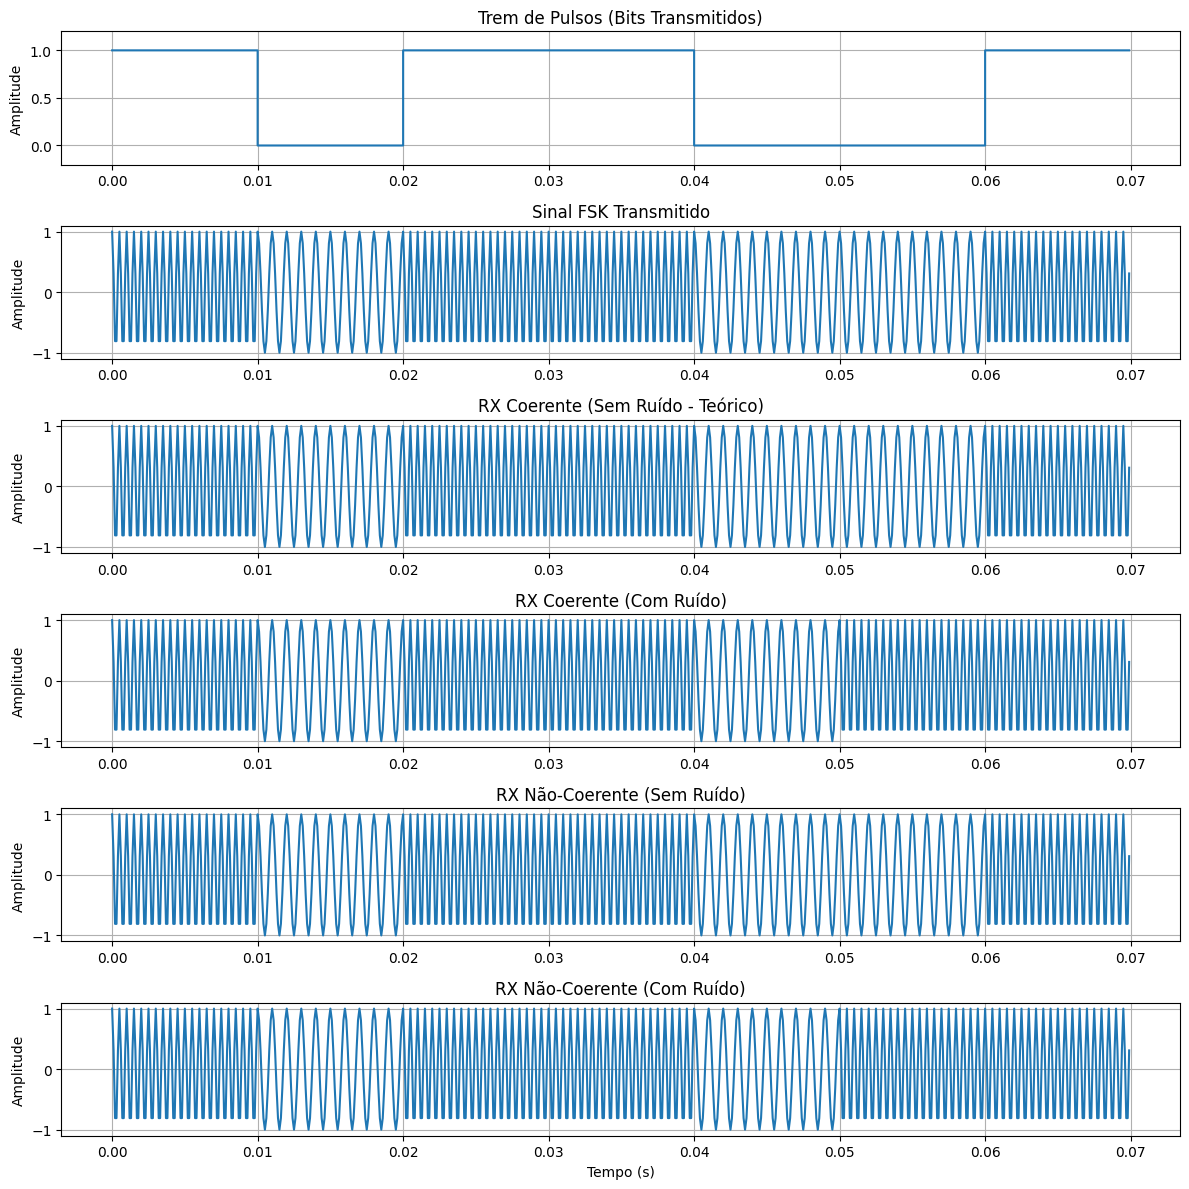

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARÂMETROS DO SISTEMA
# ============================================================

Fs = 10000           # Frequência de amostragem (Hz)
Tb = 0.01            # Duração de cada bit (s)
f0 = 1000            # Frequência associada ao bit 0 (Hz)
f1 = 2000            # Frequência associada ao bit 1 (Hz)
A = 1.0              # Amplitude da portadora

# Sequência binária transmitida
bits_tx = np.array([1, 0, 1, 1, 0, 0, 1])

# Número de amostras por bit
samples_per_bit = int(Tb * Fs)

# ============================================================
# TREM DE PULSOS (SINAL BASEBAND NRZ)
# ============================================================

# Expande cada bit para o intervalo Tb
pulse_train = np.repeat(bits_tx, samples_per_bit)

# Vetor de tempo do trem de pulsos
t_pulse = np.arange(len(pulse_train)) / Fs

# ============================================================
# MODULADOR FSK (TRANSMISSOR)
# ============================================================

def fsk_modulator(bits, f0, f1, Tb, Fs, A=1.0):
    """
    Gera o sinal FSK a partir de uma sequência binária.
    """
    t_bit = np.arange(0, Tb, 1 / Fs)
    signal = np.array([])

    for bit in bits:
        if bit == 0:
            s = A * np.cos(2 * np.pi * f0 * t_bit)
        else:
            s = A * np.cos(2 * np.pi * f1 * t_bit)

        signal = np.concatenate((signal, s))

    return signal

# Sinal FSK transmitido
signal_tx = fsk_modulator(bits_tx, f0, f1, Tb, Fs, A)

# ============================================================
# CANAL
# ============================================================

noise_power = 5   # Potência do ruído
noise = np.sqrt(noise_power) * np.random.randn(len(signal_tx))

# Sinais recebidos
signal_rx_noise = signal_tx + noise    # com ruído
signal_rx_clean = signal_tx            # sem ruído (teórico)

# ============================================================
# DEMODULADOR FSK NÃO‑COERENTE
# ============================================================

def fsk_demodulator_noncoherent(signal, f0, f1, Tb, Fs):
    """
    Demodulação FSK não‑coerente baseada em correlação (energia).
    """
    samples_per_bit = int(Tb * Fs)
    num_bits = int(len(signal) / samples_per_bit)

    bits_rx = []
    t_bit = np.arange(0, Tb, 1 / Fs)

    ref0 = np.cos(2 * np.pi * f0 * t_bit)
    ref1 = np.cos(2 * np.pi * f1 * t_bit)

    for i in range(num_bits):
        segment = signal[i*samples_per_bit:(i+1)*samples_per_bit]

        corr0 = np.sum(segment * ref0)
        corr1 = np.sum(segment * ref1)

        bits_rx.append(1 if corr1 > corr0 else 0)

    return np.array(bits_rx)

# ============================================================
# DEMODULADOR FSK COERENTE
# ============================================================

def fsk_demodulator_coherent(signal, f0, f1, Tb, Fs):
    """
    Demodulação FSK coerente (fase conhecida).
    """
    samples_per_bit = int(Tb * Fs)
    num_bits = int(len(signal) / samples_per_bit)

    bits_rx = []
    t_bit = np.arange(0, Tb, 1 / Fs)

    ref0 = np.cos(2 * np.pi * f0 * t_bit)
    ref1 = np.cos(2 * np.pi * f1 * t_bit)

    for i in range(num_bits):
        segment = signal[i*samples_per_bit:(i+1)*samples_per_bit]

        corr0 = np.sum(segment * ref0)
        corr1 = np.sum(segment * ref1)

        bits_rx.append(1 if corr1 > corr0 else 0)

    return np.array(bits_rx)

# ============================================================
# DEMODULAÇÃO (4 CASOS)
# ============================================================

# Coerente
bits_rx_coh_clean  = fsk_demodulator_coherent(signal_rx_clean, f0, f1, Tb, Fs)
bits_rx_coh_noise  = fsk_demodulator_coherent(signal_rx_noise, f0, f1, Tb, Fs)

# Não‑coerente
bits_rx_ncoh_clean = fsk_demodulator_noncoherent(signal_rx_clean, f0, f1, Tb, Fs)
bits_rx_ncoh_noise = fsk_demodulator_noncoherent(signal_rx_noise, f0, f1, Tb, Fs)

# ============================================================
# RECONSTRUÇÃO DOS SINAIS RECEBIDOS (PARA PLOTS)
# ============================================================

def reconstruct_fsk(bits):
    return fsk_modulator(bits, f0, f1, Tb, Fs, A)

rx_coh_clean  = reconstruct_fsk(bits_rx_coh_clean)
rx_coh_noise  = reconstruct_fsk(bits_rx_coh_noise)
rx_ncoh_clean = reconstruct_fsk(bits_rx_ncoh_clean)
rx_ncoh_noise = reconstruct_fsk(bits_rx_ncoh_noise)

# ============================================================
# RESULTADOS NO TERMINAL
# ============================================================

print("Bits transmitidos           :", bits_tx)
print("Bits RX coerente (sem ruído):", bits_rx_coh_clean)
print("Bits RX coerente (c/ ruído) :", bits_rx_coh_noise)
print("Bits RX não‑coerente (sem ruído)  :", bits_rx_ncoh_clean)
print("Bits RX não‑coerente (c/ ruído)   :", bits_rx_ncoh_noise)

# ============================================================
# PLOTS (6 GRÁFICOS)
# ============================================================

t = np.arange(len(signal_tx)) / Fs

plt.figure(figsize=(12, 12))

# 1) Trem de pulsos
plt.subplot(6, 1, 1)
plt.step(t_pulse, pulse_train, where='post')
plt.title("Trem de Pulsos (Bits Transmitidos)")
plt.ylabel("Amplitude")
plt.ylim(-0.2, 1.2)
plt.grid()

# 2) FSK transmitido
plt.subplot(6, 1, 2)
plt.plot(t, signal_tx)
plt.title("Sinal FSK Transmitido")
plt.ylabel("Amplitude")
plt.grid()

# 3) RX coerente sem ruído
plt.subplot(6, 1, 3)
plt.plot(t, rx_coh_clean)
plt.title("RX Coerente (Sem Ruído - Teórico)")
plt.ylabel("Amplitude")
plt.grid()

# 4) RX coerente com ruído
plt.subplot(6, 1, 4)
plt.plot(t, rx_coh_noise)
plt.title("RX Coerente (Com Ruído)")
plt.ylabel("Amplitude")
plt.grid()

# 5) RX não‑coerente sem ruído
plt.subplot(6, 1, 5)
plt.plot(t, rx_ncoh_clean)
plt.title("RX Não‑Coerente (Sem Ruído)")
plt.ylabel("Amplitude")
plt.grid()

# 6) RX não‑coerente com ruído
plt.subplot(6, 1, 6)
plt.plot(t, rx_ncoh_noise)
plt.title("RX Não‑Coerente (Com Ruído)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()